# Lab 07: Root-Finding Methods

A **root** (or **zero**) of a function $f$ is a value $x^*$ such that $f(x^*) = 0$.
Root-finding problems appear constantly in engineering:
- What interest rate achieves a savings goal?
- What mass of a bungee jumper produces a target velocity?
- At what operating point does a circuit balance?

This lab covers two families of methods:

| Family | Methods | Requirement |
|--------|---------|-------------|
| **Bracketing** | Bisection, False Position | Need $x_l, x_u$ with $f(x_l)\cdot f(x_u)<0$ |
| **Open** | Newton-Raphson, Secant | Need only a starting guess $x_0$ |

## Learning Objectives

By the end of this session, you will be able to:
- Identify root-finding problems in engineering contexts
- Use graphical and incremental search to bracket roots
- Implement and analyze the **Bisection** method
- Implement and analyze the **False Position** (Regula Falsi) method
- Implement and analyze the **Newton-Raphson** method
- Implement the **Secant** method for derivative-free open root-finding
- Use `scipy.optimize` for production root-finding
- Compare convergence rates and trade-offs of all methods

## Session Outline

| # | Topic |  
|---|-------| 
| 1 | Motivation and Graphical Approach |  
| 2 | Incremental (Sign-Change) Search | 
| 3 | Bisection Method |  
| 4 | False Position (Regula Falsi) |  
| 5 | Newton-Raphson Method |  
| 6 | Secant Method |  
| 7 | `scipy.optimize` and Method Comparison |  

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, root_scalar
from functools import partial

---
## 1. Motivation and Graphical Approach

### 1.1 Engineering Problem: Savings Account

Shin deposits $p$ dollars per month at annual interest rate $r$.
After $n$ payments the total amount is:
$$A = \frac{12p}{r}\left[\left(1+\frac{r}{12}\right)^n - 1\right]$$

**Goal:** find $r$ such that $A = \$1500$ after $n=24$ months of $\$60$ deposits.
Define $f(r) = \frac{12p}{r}\left[(1+r/12)^n - 1\right] - A = 0$.

### 1.2 Engineering Problem: Bungee Jumper (Running Example)

The velocity of a falling bungee jumper with mass $m$ at time $t$ is:
$$v(m) = \sqrt{\frac{mg}{c_d}} \tanh\!\left(\sqrt{\frac{c_d g}{m}}\, t\right)$$

**Goal:** find mass $m$ such that $v = 36$ m/s at $t = 4$ s with $c_d = 0.25$ kg/m.
Define $f(m) = \sqrt{mg/c_d}\,\tanh\!\left(\sqrt{c_d g/m}\,t\right) - v = 0$.

A **graphical approach** is not precise but quickly tells us where the root is.

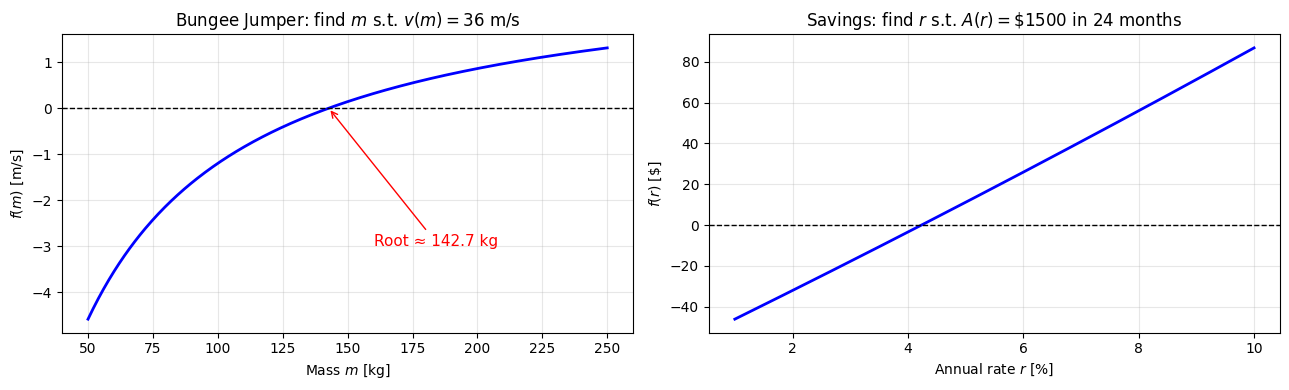

In [3]:
# Problem parameters
cd, g_acc, v_target, t_fall = 0.25, 9.81, 36.0, 4.0
deposit, duration, target_amount = 60.0, 24, 1500.0

# Define the two root-finding functions
def f_bungee(m):
    """f(m) = v(m) - v_target  (bungee jumper mass problem)"""
    return np.sqrt(m * g_acc / cd) * np.tanh(np.sqrt(cd * g_acc / m) * t_fall) - v_target

def f_savings(r):
    """f(r) = A(r) - target  (savings account interest rate)"""
    ratio = 1.0 + r / 12.0
    return 12.0 * deposit / r * (ratio**duration - 1.0) - target_amount

# Graphical approach: plot both functions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bungee jumper
m_arr = np.linspace(50, 250, 400)
ax = axes[0]
ax.plot(m_arr, f_bungee(m_arr), 'b-', lw=2)
ax.axhline(0, color='k', lw=1, ls='--')
ax.set(xlabel='Mass $m$ [kg]', ylabel='$f(m)$ [m/s]',
       title='Bungee Jumper: find $m$ s.t. $v(m)=36$ m/s')
ax.grid(True, alpha=0.3)
ax.annotate('Root ≈ 142.7 kg', xy=(142.7, 0), xytext=(160, -3),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=11)

# Savings
r_arr = np.linspace(0.01, 0.10, 400)
ax = axes[1]
ax.plot(r_arr * 100, f_savings(r_arr), 'b-', lw=2)
ax.axhline(0, color='k', lw=1, ls='--')
ax.set(xlabel='Annual rate $r$ [%]', ylabel='$f(r)$ [\$]',
       title='Savings: find $r$ s.t. $A(r)=\$1500$ in 24 months')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The graph shows that the bungee jumper root is somewhere in $[50, 250]$.
We see $f(50) < 0$ and $f(250) > 0$, so there is at least one root in this bracket.

**Key principle (Intermediate Value Theorem):**  
If $f$ is continuous and $f(x_l) \cdot f(x_u) < 0$, then at least one root exists in $[x_l, x_u]$.

In [4]:
# Verify sign change for both problems
print('=== Bungee Jumper ===')
xl, xu = 50.0, 250.0
print(f'f({xl}) = {f_bungee(xl):.4f}')
print(f'f({xu}) = {f_bungee(xu):.4f}')
print(f'Sign change? {f_bungee(xl) * f_bungee(xu) < 0}')

print('\n=== Savings Account ===')
rl, ru = 0.01, 0.10
print(f'f({rl:.2f}) = {f_savings(rl):.4f}')
print(f'f({ru:.2f}) = {f_savings(ru):.4f}')
print(f'Sign change? {f_savings(rl) * f_savings(ru) < 0}')

=== Bungee Jumper ===
f(50.0) = -4.5794
f(250.0) = 1.3082
Sign change? True

=== Savings Account ===
f(0.01) = -46.1153
f(0.10) = 86.8149
Sign change? True


---
## 2. Incremental (Sign-Change) Search

Before applying any root-finding method, we need to **locate brackets**.
The incremental search divides $[x_{\min}, x_{\max}]$ into $n_s - 1$ equal subintervals
and checks each for a sign change.

**Algorithm:**
1. Create $n_s$ equally-spaced points $x_0, x_1, \ldots, x_{n_s-1}$ in $[x_{\min}, x_{\max}]$
2. For each pair $(x_k, x_{k+1})$: if $f(x_k) \cdot f(x_{k+1}) < 0$, record the bracket
3. Return all brackets found

**Limitation:** a bracket may contain an even number of roots (missed!) if $n_s$ is too small.

In [33]:
def incsearch(func, xmin, xmax, ns=50):
    """
    Find all sign-change brackets of func in [xmin, xmax].

    Parameters
    ----------
    func : callable
    xmin, xmax : float  — search interval
    ns   : int          — number of points (ns-1 subintervals)

    Returns
    -------
    nb   : int          — number of brackets found
    xb   : list of (xl, xu) tuples
    """
    x = np.linspace(xmin, xmax, ns)
    nb = 0
    xb = []

    for k in range(ns - 1):
        # --- COMPLETE: detect sign change between x[k] and x[k+1] ---
        if                                              func(x[k]) * func(x[k+1]) < 0:
            nb += 1
            xb.append((x[k], x[k+1]))
        # --- COMPLETE ---

    return nb, xb

<!-- SOLUTION
if func(x[k]) * func(x[k+1]) < 0:
-->

ns= 20  ->  7 bracket(s) found
ns= 50  ->  5 bracket(s) found
ns=100  ->  9 bracket(s) found

Brackets (ns=100):
  [3.2424, 3.2727]
  [3.3636, 3.3939]
  [3.7273, 3.7576]
  [4.2121, 4.2424]
  [4.2424, 4.2727]
  [4.6970, 4.7273]
  [5.1515, 5.1818]
  [5.1818, 5.2121]
  [5.6667, 5.6970]


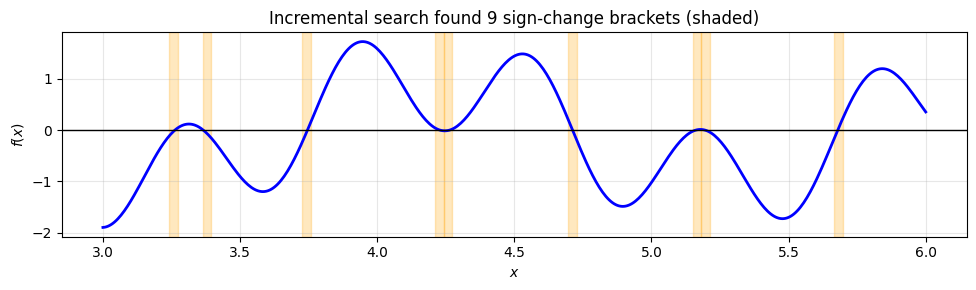

In [34]:
# Test incsearch on a function with multiple roots
f_multi = lambda x: np.sin(10 * x) + np.cos(3 * x)
xmin, xmax = 3.0, 6.0

for ns in [20, 50, 100]:
    nb, xb = incsearch(f_multi, xmin, xmax, ns=ns)
    print(f'ns={ns:3d}  ->  {nb} bracket(s) found')

# Best result
nb, xb = incsearch(f_multi, xmin, xmax, ns=100)
print(f'\nBrackets (ns=100):')
for xl_b, xu_b in xb:
    print(f'  [{xl_b:.4f}, {xu_b:.4f}]')

# Visual
x_plot = np.linspace(xmin, xmax, 500)
plt.figure(figsize=(10, 3))
plt.plot(x_plot, f_multi(x_plot), 'b-', lw=2)
plt.axhline(0, color='k', lw=1)
for xl_b, xu_b in xb:
    plt.axvspan(xl_b, xu_b, alpha=0.25, color='orange')
plt.xlabel('$x$'); plt.ylabel('$f(x)$')
plt.title(f'Incremental search found {nb} sign-change brackets (shaded)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

---
## 3. Bisection Method

### 3.1 Algorithm

Given a bracket $[x_l, x_u]$ with $f(x_l)\cdot f(x_u) < 0$:

1. Compute midpoint: $x_r = \dfrac{x_l + x_u}{2}$
2. Compute approximate relative error: $\varepsilon_a = \left|\dfrac{x_r^{\rm new} - x_r^{\rm old}}{x_r^{\rm new}}\right| \times 100\%$
3. Update bracket:
   - If $f(x_l)\cdot f(x_r) < 0$: root is in $[x_l, x_r]$ → set $x_u = x_r$
   - Else: root is in $[x_r, x_u]$ → set $x_l = x_r$
4. Repeat until $\varepsilon_a < \varepsilon_s$ or maximum iterations reached

### 3.2 Convergence

The bracket width is halved at each step:
$$\text{error after } n \text{ iterations} \leq \frac{x_u - x_l}{2^n}$$

This is **linear convergence** with rate $r = 0.5$.
The minimum number of iterations to achieve absolute tolerance $\varepsilon_{\rm abs}$:
$$n \geq \left\lceil \log_2\!\left(\frac{x_u - x_l}{\varepsilon_{\rm abs}}\right) \right\rceil$$

**Advantage:** always converges if the initial bracket is valid.  
**Disadvantage:** slow (linear) convergence.

In [5]:
def bisect(func, xl, xu, es=1e-7, maxit=50):
    """
    Find a root of func in [xl, xu] using the bisection method.

    Parameters
    ----------
    func : callable — continuous function
    xl, xu : float  — initial bracket  (must satisfy f(xl)*f(xu) < 0)
    es     : float  — stopping criterion (approx. relative error)
    maxit  : int    — maximum iterations

    Returns
    -------
    xr      : float — root estimate
    fxr     : float — f(xr)
    ea      : float — final approximate relative error
    n_iter  : int   — iterations performed
    history : list of (iter, xr, f(xr), ea)
    """
    if func(xl) * func(xu) > 0:
        raise ValueError('f(xl) and f(xu) must have opposite signs (bracket check failed)')

    xr_old = xl       # previous midpoint (initialized to xl)
    history = []

    for i in range(maxit):
        # --- COMPLETE ---
        xr =                                (xl + xu) / 2  # — midpoint
        ea = abs((xr - xr_old) / xr) if xr != 0 else abs(xr - xr_old)  # approx. relative error

        if func(xl) * func(xr) < 0:     #  — sign test: root in left half?
            xu = xr
        else:
            xl =                             xr #      — root in right half
        # --- COMPLETE ---

        history.append((i + 1, xr, func(xr), ea))
        xr_old = xr

        if ea < es:
            break

    return xr, func(xr), ea, i + 1, history

<!-- SOLUTION
xr = (xl + xu) / 2
if func(xl) * func(xr) < 0:
    xu = xr
else:
    xl = xr
-->

In [6]:
# Apply bisection to the bungee jumper problem
m_true = 142.7376  # known true root (for error analysis)

xr, fxr, ea, n_iter, history = bisect(f_bungee, 50, 250, es=1e-9, maxit=60)

print(f'Root found : m = {xr:.8f} kg')
print(f'f(root)    : {fxr:.3e}')
print(f'Rel. error : {ea:.3e}')
print(f'Iterations : {n_iter}')

# Print iteration table
print(f'\n{"Iter":>5}  {"xr":>14}  {"f(xr)":>14}  {"ea":>12}')
print('-' * 52)
for row in history:
    print(f'{row[0]:>5}  {row[1]:>14.8f}  {row[2]:>14.6e}  {row[3]:>12.6e}')

Root found : m = 142.73763308 kg
f(root)    : -5.203e-10
Rel. error : 6.525e-10
Iterations : 31

 Iter              xr           f(xr)            ea
----------------------------------------------------
    1    150.00000000    1.420430e-01  6.666667e-01
    2    100.00000000   -1.197380e+00  5.000000e-01
    3    125.00000000   -4.086015e-01  2.000000e-01
    4    137.50000000   -1.108041e-01  9.090909e-02
    5    143.75000000    2.057713e-02  4.347826e-02
    6    140.62500000   -4.379968e-02  2.222222e-02
    7    142.18750000   -1.129258e-02  1.098901e-02
    8    142.96875000    4.720768e-03  5.464481e-03
    9    142.57812500   -3.266139e-03  2.739726e-03
   10    142.77343750    7.322383e-04  1.367989e-03
   11    142.67578125   -1.265717e-03  6.844627e-04
   12    142.72460938   -2.664315e-04  3.421143e-04
   13    142.74902344    2.329804e-04  1.710279e-04
   14    142.73681641   -1.670630e-05  8.552125e-05
   15    142.74291992    1.081418e-04  4.275880e-05
   16    142.73986

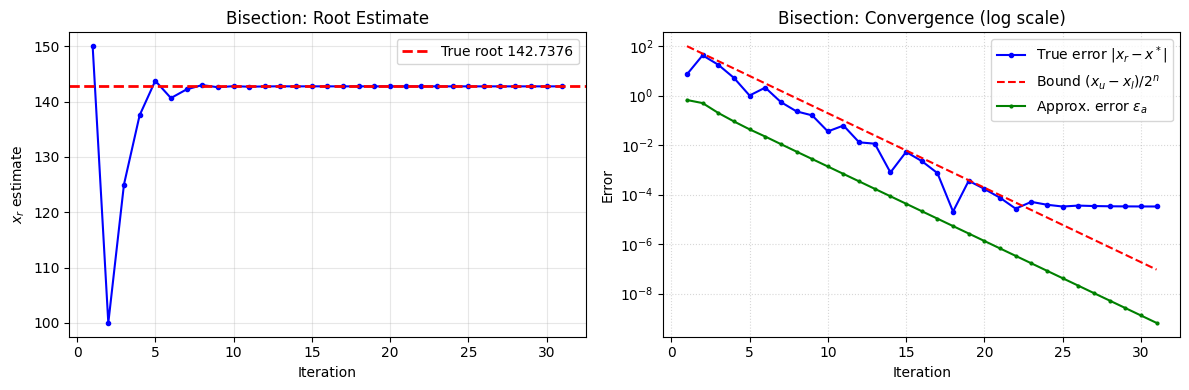

To achieve |error| < 1e-06: need at least 28 iterations  (theory: ceil(log2(200/1e-06)))


In [7]:
# Convergence analysis
iters_bs = [row[0] for row in history]
xr_vals  = [row[1] for row in history]
true_err = [abs(row[1] - m_true) for row in history]
ea_vals  = [row[3] for row in history]

# Theoretical: error <= (xu - xl) / 2^n
theo_err = [(250 - 50) / 2**k for k in iters_bs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(iters_bs, xr_vals, 'b.-', ms=6)
ax.axhline(m_true, color='r', ls='--', lw=2, label=f'True root {m_true}')
ax.set(xlabel='Iteration', ylabel='$x_r$ estimate', title='Bisection: Root Estimate')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(iters_bs, true_err, 'b.-', ms=6, label='True error $|x_r - x^*|$')
ax.semilogy(iters_bs, theo_err, 'r--', lw=1.5, label='Bound $(x_u-x_l)/2^n$')
ax.semilogy(iters_bs, ea_vals,  'g.-', ms=4, label='Approx. error $\\varepsilon_a$')
ax.set(xlabel='Iteration', ylabel='Error', title='Bisection: Convergence (log scale)')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Theoretical number of iterations needed
eps_abs = 1e-6
n_theo = np.ceil(np.log2((250 - 50) / eps_abs))
print(f'To achieve |error| < {eps_abs}: need at least {n_theo:.0f} iterations  '
      f'(theory: ceil(log2(200/{eps_abs})))')

### Convergence slope and order

**Error bound.** After $n$ iterations, the true error satisfies

$$|x_n - x^*| \;\le\; \frac{x_u - x_l}{2^{n}}.$$

Taking $\log_{10}$ of both sides,

$$\log_{10}|x_n - x^*| \;\le\; \log_{10}(x_u - x_l) \;-\; n\,\log_{10} 2.$$

So on a **semilog plot** of error versus iteration $n$, the theoretical bound is a straight line with slope

$$\text{slope} \;=\; -\log_{10} 2 \;\approx\; -0.301.$$

Each iteration shrinks the error bound by a factor of $2$ — about **0.301 decades** — which corresponds to gaining roughly **one decimal digit every $1/0.301 \approx 3.3$ iterations**. In the plot above, the red dashed line $(x_u-x_l)/2^n$ has exactly this slope, and the blue true-error curve stays at or below it.

**Order of convergence.** Bisection satisfies

$$e_{n+1} \;\approx\; \tfrac{1}{2}\, e_n,$$

so it is **linear convergence** (order $p = 1$) with asymptotic error constant $C = 1/2$. This is slow compared with the quadratic convergence of Newton–Raphson ($p = 2$), but it is guaranteed as long as the initial bracket contains a sign change.

**Exercise:** Use `bisect` to find the interest rate in the savings account problem.
Start with the bracket $[0.01, 0.10]$ and a tolerance $\varepsilon_s = 10^{-8}$.
How many iterations does it take?

In [ ]:
# Apply bisect to f_savings with bracket [0.01, 0.10]
r_root, fr_root, ea_r, n_iter_r, hist_r = bisect(f_savings, 0.01, 0.10, es=1e-8, maxit=200)

print(f'Interest rate : r = {r_root:.10f}  ({r_root*100:.6f} %)')
print(f'f(r)          : {fr_root:.3e}')
print(f'Approx. error : {ea_r:.3e}')
print(f'Iterations    : {n_iter_r}')

# Compare with the theoretical bound:  n >= log2((xu - xl) / eps)
n_theo_r = int(np.ceil(np.log2((0.10 - 0.01) / 1e-8)))
print(f'\nTheoretical minimum iterations for |error| < 1e-8: {n_theo_r}')

---
## 4. False Position (Regula Falsi)

### 4.1 Algorithm

Instead of bisecting at the **midpoint**, False Position (Regula Falsi) finds the x-intercept of the
**line** connecting $(x_l, f(x_l))$ and $(x_u, f(x_u))$:

$$x_r = x_u - f(x_u)\,\frac{x_l - x_u}{f(x_l) - f(x_u)}$$

This is equivalent to linear interpolation: if $f$ is approximately linear on $[x_l, x_u]$,
this gives a better estimate than the midpoint.

The bracket update rule is the same as bisection (sign test).

### 4.2 Geometric Interpretation

```
  f(xl) *
          \                 <- True f(x)
           \    ___---
  0 --------\--/--------  x-axis
              \/ <- xr (line intercept)
          *  f(xu)
```

**Note:** One bracket endpoint often stays fixed for many iterations if $f$ is strongly curved.
This can make False Position **slower than bisection** in some cases.

In [ ]:
# Visualize the False Position step geometrically
xl_vis, xu_vis = 50.0, 250.0
m_plot = np.linspace(40, 260, 400)

xr_vis = xu_vis - f_bungee(xu_vis) * (xl_vis - xu_vis) / (f_bungee(xl_vis) - f_bungee(xu_vis))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m_plot, f_bungee(m_plot), 'b-', lw=2, label='$f(m)$')
ax.axhline(0, color='k', lw=1)
ax.plot([xl_vis, xu_vis], [f_bungee(xl_vis), f_bungee(xu_vis)], 'r-o', lw=1.5,
        ms=8, label='Secant line')
ax.plot(xr_vis, 0, 'r*', ms=16, zorder=5, label=f'$x_r$ = {xr_vis:.2f} kg')
ax.plot(m_true, 0, 'g*', ms=16, zorder=5, label=f'True root = {m_true:.4f} kg')
ax.axvline(xl_vis, color='gray', ls=':', lw=1)
ax.axvline(xu_vis, color='gray', ls=':', lw=1)
ax.text(xl_vis, f_bungee(xl_vis) - 1, '$x_l$', ha='center', fontsize=12)
ax.text(xu_vis, f_bungee(xu_vis) + 0.3, '$x_u$', ha='center', fontsize=12)
ax.set(xlabel='Mass $m$ [kg]', ylabel='$f(m)$ [m/s]',
       title='False Position: First Step')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Midpoint (bisection):      {(xl_vis+xu_vis)/2:.4f} kg')
print(f'False position estimate:   {xr_vis:.4f} kg')
print(f'True root:                 {m_true:.4f} kg')

In [35]:
def false_position(func, xl, xu, es=1e-7, maxit=50):
    """
    Find a root of func in [xl, xu] using the False Position (Regula Falsi) method.

    Parameters
    ----------
    func : callable
    xl, xu : float  — initial bracket
    es     : float  — stopping criterion (approx. relative error)
    maxit  : int    — maximum iterations

    Returns
    -------
    xr, f(xr), ea, n_iter, history
    """
    if func(xl) * func(xu) > 0:
        raise ValueError('f(xl) and f(xu) must have opposite signs')

    xr_old = xl
    history = []

    for i in range(maxit):
        fl, fu = func(xl), func(xu)

        # --- COMPLETE: linear interpolation (secant line x-intercept) ---
        xr =                                xu - fu * (xl - xu) / (fl - fu)
        # --- COMPLETE ---

        fr = func(xr)
        ea = abs((xr - xr_old) / xr) if xr != 0 else abs(xr - xr_old)

        history.append((i + 1, xr, fr, ea))
        xr_old = xr

        if ea < es:
            break

        if fl * fr < 0:
            xu = xr
        else:
            xl = xr

    return xr, func(xr), ea, i + 1, history

<!-- SOLUTION
xr = xu - fu * (xl - xu) / (fl - fu)
-->

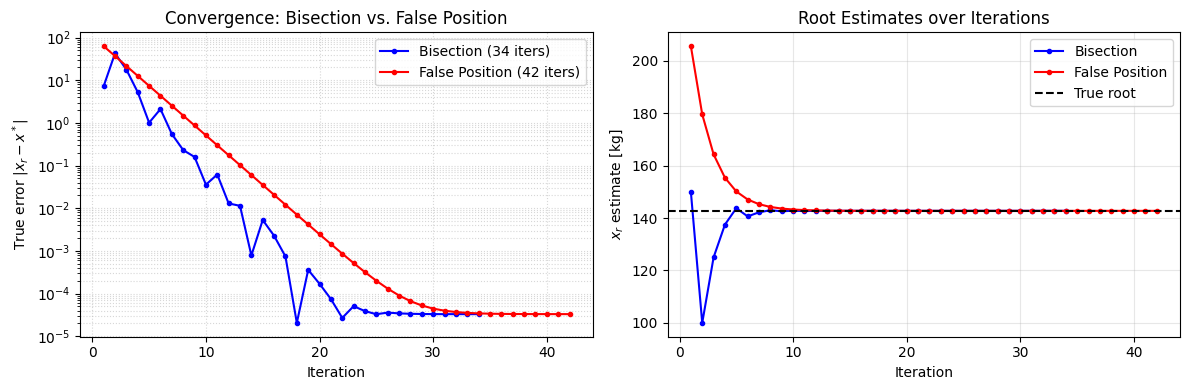

Bisection:      34 iterations,  final |error| = 3.312e-05
False Position: 42 iterations,  final |error| = 3.313e-05


In [36]:
# Compare bisection vs. false position on the bungee jumper problem
xr_bs, _, _, _, hist_bs = bisect(f_bungee, 50, 250, es=1e-10, maxit=60)
xr_fp, _, _, _, hist_fp = false_position(f_bungee, 50, 250, es=1e-10, maxit=60)

err_bs = [abs(row[1] - m_true) for row in hist_bs]
err_fp = [abs(row[1] - m_true) for row in hist_fp]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(range(1, len(err_bs)+1), err_bs, 'b.-', ms=6, label=f'Bisection ({len(err_bs)} iters)')
ax.semilogy(range(1, len(err_fp)+1), err_fp, 'r.-', ms=6, label=f'False Position ({len(err_fp)} iters)')
ax.set(xlabel='Iteration', ylabel='True error $|x_r - x^*|$',
       title='Convergence: Bisection vs. False Position')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=0.5)

# Show how the bracket evolves: does one side stay fixed?
ax = axes[1]
xr_hist_fp = [row[1] for row in hist_fp]
xr_hist_bs = [row[1] for row in hist_bs]
ax.plot(range(1, len(xr_hist_bs)+1), xr_hist_bs, 'b.-', ms=6, label='Bisection')
ax.plot(range(1, len(xr_hist_fp)+1), xr_hist_fp, 'r.-', ms=6, label='False Position')
ax.axhline(m_true, color='k', ls='--', lw=1.5, label=f'True root')
ax.set(xlabel='Iteration', ylabel='$x_r$ estimate [kg]',
       title='Root Estimates over Iterations')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Bisection:      {len(hist_bs):2d} iterations,  final |error| = {err_bs[-1]:.3e}')
print(f'False Position: {len(hist_fp):2d} iterations,  final |error| = {err_fp[-1]:.3e}')

---
## 5. Newton-Raphson Method

### 5.1 Algorithm

The **Newton-Raphson method** uses the derivative $f'(x)$ to construct a tangent line
at the current guess and finds its x-intercept as the next guess:

$$x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

**Geometric interpretation:** at $x_i$, draw the tangent line $y = f(x_i) + f'(x_i)(x - x_i)$.
Set $y = 0$ and solve for $x$ to get $x_{i+1}$.

### 5.2 Convergence: Quadratic!

Near the root $x^*$, the error $e_i = x_i - x^*$ satisfies:
$$e_{i+1} \approx -\frac{f''(x^*)}{2f'(x^*)}\, e_i^2$$

This is **quadratic convergence**: the number of correct decimal digits roughly **doubles** each iteration.

**Requirements:**
- Need $f'(x)$ analytically
- May diverge if $f'(x_i) \approx 0$ or starting guess is poor

### 5.3 When Newton-Raphson Fails

| Failure Mode | Cause | Remedy |
|-------------|-------|--------|
| Divergence | Initial guess too far from root | Use bracketing first |
| Oscillation | Local extremum near root | Use smaller step or bisection |
| Zero derivative | $f'(x_i) \approx 0$ | Add small perturbation or switch method |

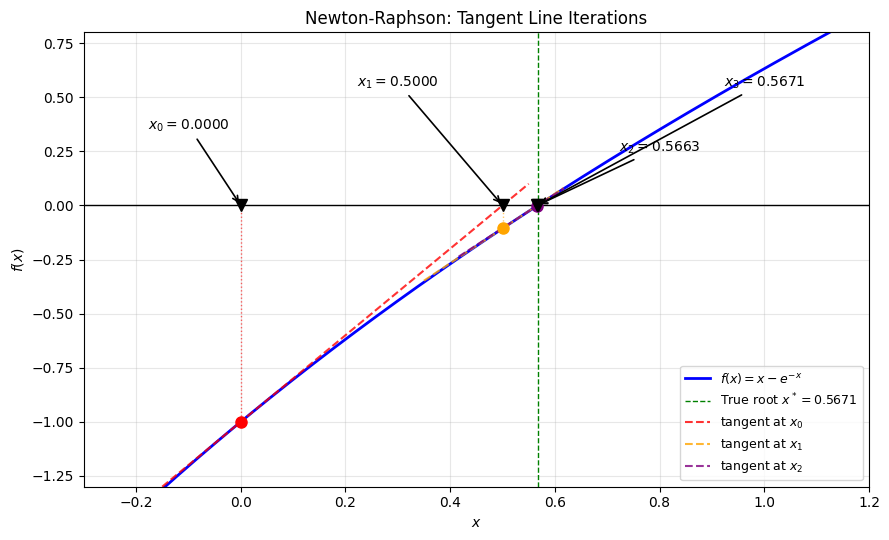

In [21]:
# Visualize the Newton-Raphson steps
f_nr   = lambda x: x - np.exp(-x)           # f(x) = x - e^{-x}, root ≈ 0.5671
fp_nr  = lambda x: 1.0 + np.exp(-x)         # f'(x)
x_true = 0.5671432904097838

x_plot = np.linspace(-0.3, 1.2, 300)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(x_plot, f_nr(x_plot), 'b-', lw=2, label='$f(x) = x - e^{-x}$')
ax.axhline(0, color='k', lw=1)
ax.axvline(x_true, color='g', ls='--', lw=1, label=f'True root $x^*={x_true:.4f}$')

# Iteration sequence x_0, x_1, x_2, x_3
xs = [0.0]
for _ in range(3):
    xi = xs[-1]
    xs.append(xi - f_nr(xi) / fp_nr(xi))

# Tangent lines and curve points for the 3 Newton-Raphson steps
colors = ['red', 'orange', 'purple']
for step, col in enumerate(colors):
    xi   = xs[step]
    xi1  = xs[step + 1]
    fxi  = f_nr(xi)
    fpxi = fp_nr(xi)
    x_tan = np.linspace(min(xi, xi1) - 0.15, max(xi, xi1) + 0.05, 50)
    y_tan = fxi + fpxi * (x_tan - xi)
    ax.plot(x_tan, y_tan, '--', color=col, lw=1.5, alpha=0.8,
            label=f'tangent at $x_{step}$')
    # Vertical drop from (x_i, f(x_i)) to (x_i, 0)
    ax.plot([xi, xi], [0, fxi], ':', color=col, lw=1, alpha=0.6)
    # Point on the curve
    ax.plot(xi, fxi, 'o', color=col, ms=8, zorder=5)

# Mark each x_i on the x-axis
for xv in xs:
    ax.plot(xv, 0, 'v', color='black', ms=9, zorder=6)

# Arrows pointing exactly to the x-axis position of each x_i
label_pos = [(-0.10, 0.35), (0.30, 0.55), (0.80, 0.25), (1.00, 0.55)]
for i, (lx, ly) in enumerate(label_pos):
    ax.annotate(f'$x_{i}={xs[i]:.4f}$',
                xy=(xs[i], 0), xycoords='data',
                xytext=(lx, ly), textcoords='data',
                fontsize=10, ha='center',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.set(xlim=[-0.3, 1.2], ylim=[-1.3, 0.8],
       xlabel='$x$', ylabel='$f(x)$',
       title='Newton-Raphson: Tangent Line Iterations')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

<!-- xi - fxi / fpxi  # Newton-Raphson update --> 

In [ ]:
def newtraph(f, fp, x0, es=1e-7, maxit=30):
    """
    Find a root of f using the Newton-Raphson method.

    Parameters
    ----------
    f    : callable — function
    fp   : callable — derivative of f
    x0   : float   — initial guess
    es   : float   — stopping criterion (approx. relative error)
    maxit: int     — maximum iterations

    Returns
    -------
    x1, f(x1), ea, n_iter, history
    """
    history = []
    xi = x0

    for i in range(maxit):
        fxi  = f(xi)
        fpxi = fp(xi)

        if abs(fpxi) < 1e-30:
            raise ZeroDivisionError('Derivative near zero — Newton-Raphson fails')

        # --- COMPLETE ---
        x1 =                                # — Newton-Raphson update
        ea = abs((x1 - xi) / x1) if x1 != 0 else abs(x1 - xi)
        # --- COMPLETE ---

        history.append((i + 1, x1, f(x1), ea))

        if ea < es:
            break

        xi = x1

    return x1, f(x1), ea, i + 1, history

<!-- SOLUTION
x1 = xi - fxi / fpxi
-->

In [23]:
# Test newtraph on f(x) = x - e^{-x}, root = 0.5671...
xr_nr, fxr_nr, ea_nr, n_nr, hist_nr = newtraph(f_nr, fp_nr, x0=0.0, es=1e-12, maxit=20)

print(f'Root found : {xr_nr:.15f}')
print(f'True root  : {x_true:.15f}')
print(f'|error|    : {abs(xr_nr - x_true):.3e}')
print(f'Iterations : {n_nr}')

print(f'\n{"Iter":>5}  {"xi":>18}  {"f(xi)":>14}  {"ea":>14}')
print('-' * 58)
for row in hist_nr:
    print(f'{row[0]:>5}  {row[1]:>18.12f}  {row[2]:>14.6e}  {row[3]:>14.6e}')

Root found : 0.567143290409784
True root  : 0.567143290409784
|error|    : 1.110e-16
Iterations : 5

 Iter                  xi           f(xi)              ea
----------------------------------------------------------
    1      0.500000000000   -1.065307e-01    1.000000e+00
    2      0.566311003197   -1.304510e-03    1.170929e-01
    3      0.567143165035   -1.964805e-07    1.467287e-03
    4      0.567143290410   -4.440892e-15    2.210639e-07
    5      0.567143290410    1.110223e-16    5.089684e-15


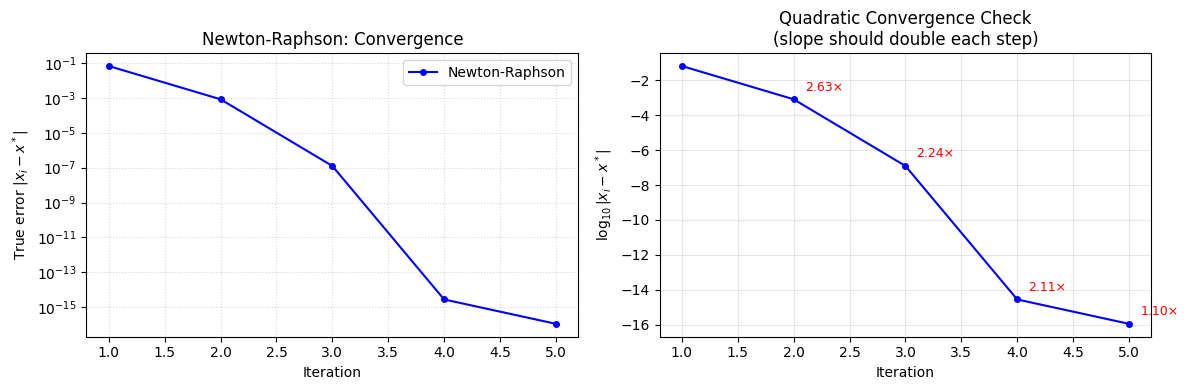

Ratios log10(e_{i+1}) / log10(e_i)  (should approach 2.0 for quadratic convergence):
  iter 1->2: 2.6255
  iter 2->3: 2.2410
  iter 3->4: 2.1091
  iter 4->5: 1.0960


In [24]:
# Demonstrate quadratic convergence: log(error) doubles each step
err_nr = [abs(row[1] - x_true) for row in hist_nr]
err_nr = [e for e in err_nr if e > 0]  # remove exact zeros for log plot

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(range(1, len(err_nr)+1), err_nr, 'b.-', ms=8, label='Newton-Raphson')
ax.set(xlabel='Iteration', ylabel='True error $|x_i - x^*|$',
       title='Newton-Raphson: Convergence')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=0.5)

ax = axes[1]
log_err = np.log10(err_nr)
ax.plot(range(1, len(log_err)+1), log_err, 'b.-', ms=8)
# Quadratic convergence: log10(e_{i+1}) ≈ 2 * log10(e_i) + const
# Check by plotting consecutive errors
ax.set(xlabel='Iteration', ylabel='$\\log_{10}|x_i - x^*|$',
       title='Quadratic Convergence Check\n(slope should double each step)')
for k in range(len(log_err)-1):
    ax.annotate(f'{log_err[k+1]/log_err[k]:.2f}×',
                xy=(k+2, log_err[k+1]), xytext=(k+2.1, log_err[k+1]+0.5),
                fontsize=9, color='red')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Ratios log10(e_{i+1}) / log10(e_i)  (should approach 2.0 for quadratic convergence):')
for k in range(len(log_err)-1):
    print(f'  iter {k+1}->{k+2}: {log_err[k+1]/log_err[k]:.4f}')

In [25]:
# Apply Newton-Raphson to the bungee jumper problem
# f(m) = sqrt(m*g/cd)*tanh(sqrt(cd*g/m)*t) - v
# f'(m): compute analytically
def fp_bungee(m):
    """Analytical derivative df/dm for the bungee jumper function."""
    alpha = np.sqrt(cd * g_acc / m)
    beta  = np.sqrt(m * g_acc / cd)
    return 0.5 * (g_acc / cd) / beta * np.tanh(alpha * t_fall) \
         - beta * (1.0 / np.cosh(alpha * t_fall))**2 * alpha * t_fall / (2.0 * m)

xr_nr2, fxr_nr2, ea_nr2, n_nr2, hist_nr2 = newtraph(f_bungee, fp_bungee, x0=140.0, es=1e-10)
print(f'Newton-Raphson bungee: m = {xr_nr2:.10f} kg  ({n_nr2} iterations)')
print(f'Bisection (50 iters): m = {xr_bs:.10f} kg')

Newton-Raphson bungee: m = 142.7376331084 kg  (4 iterations)
Bisection (50 iters): m = 142.7376331179 kg


**Exercise:** Apply `newtraph` to the savings account problem.
The derivative of $f(r) = \frac{12p}{r}\left[(1+r/12)^n - 1\right] - A$ with respect to $r$ is:
$$f'(r) = -\frac{12p}{r^2}\left[(1+r/12)^n - 1\right] + \frac{12p}{r} \cdot n(1+r/12)^{n-1} \cdot \frac{1}{12}$$

Starting from $r_0 = 0.05$, how many iterations does Newton-Raphson need?

In [27]:
# Define fp_savings(r) and apply newtraph
def fp_savings(r):
    ratio = 1.0 + r / 12.0
    term1 = -12.0 * deposit / r**2 * (ratio**duration - 1.0)
    term2 =  12.0 * deposit / r * duration * ratio**(duration - 1) / 12.0
    return term1 + term2

# Apply newtraph to f_savings starting at r0=0.05
r_nr, fr_nr, ea_nr_r, n_nr_r, hist_nr_r = newtraph(f_savings, fp_savings,
                                                    x0=0.05, es=1e-12, maxit=30)

print(f'Interest rate : r = {r_nr:.12f}  ({r_nr*100:.8f} %)')
print(f'f(r)          : {fr_nr:.3e}')
print(f'Approx. error : {ea_nr_r:.3e}')
print(f'Iterations    : {n_nr_r}')

# Iteration table
print(f'\n{"Iter":>5}  {"r":>16}  {"f(r)":>14}  {"ea":>12}')
print('-' * 56)
for row in hist_nr_r:
    print(f'{row[0]:>5}  {row[1]:>16.12f}  {row[2]:>14.6e}  {row[3]:>12.6e}')

Interest rate : r = 0.042361034429  (4.23610344 %)
f(r)          : 2.228e-11
Approx. error : 5.799e-13
Iterations    : 4

 Iter                 r            f(r)            ea
--------------------------------------------------------
    1    0.042396733201    5.188834e-02  1.793361e-01
    2    0.042361035211    1.136135e-06  8.427082e-04
    3    0.042361034429    3.569767e-11  1.845255e-08
    4    0.042361034429    2.228262e-11  5.798651e-13


---
## 6. Secant Method

### 6.1 Motivation

Computing $f'(x)$ analytically is sometimes difficult or expensive.
The **Secant method** approximates the derivative using two previous iterates:

$$f'(x_i) \approx \frac{f(x_i) - f(x_{i-1})}{x_i - x_{i-1}}$$

Substituting into the Newton-Raphson formula:
$$x_{i+1} = x_i - f(x_i)\,\frac{x_{i-1} - x_i}{f(x_{i-1}) - f(x_i)}$$

### 6.2 Convergence

The secant method converges with order $\phi = \frac{1+\sqrt{5}}{2} \approx 1.618$ (the golden ratio) —
**superlinear** but slower than Newton-Raphson's quadratic convergence.

| Method | Order | Evaluations/step | Effective rate |
|--------|-------|-----------------|----------------|
| Newton-Raphson | 2 (quadratic) | $f$ + $f'$ | High |
| Secant | 1.618 | $f$ only | Medium |
| Bisection | 1 (linear) | $f$ only | Slow |

In [28]:
def secant(f, x0, x1, es=1e-7, maxit=30):
    """
    Find a root of f using the Secant method.

    Parameters
    ----------
    f     : callable — function (no derivative needed)
    x0, x1: float   — two initial guesses (do NOT need to bracket the root)
    es    : float   — stopping criterion
    maxit : int     — maximum iterations

    Returns
    -------
    x2, f(x2), ea, n_iter, history
    """
    history = []

    for i in range(maxit):
        f0, f1 = f(x0), f(x1)

        if abs(f1 - f0) < 1e-30:
            raise ZeroDivisionError('f(x1) ≈ f(x0) — secant method fails (zero denominator)')

        # --- COMPLETE: secant update formula ---
        x2 =                                x1 - f1 * (x0 - x1) / (f0 - f1)
        # --- COMPLETE ---

        ea = abs((x2 - x1) / x2) if x2 != 0 else abs(x2 - x1)
        history.append((i + 1, x2, f(x2), ea))

        if ea < es:
            break

        x0, x1 = x1, x2

    return x2, f(x2), ea, i + 1, history

<!-- SOLUTION
x2 = x1 - f1 * (x0 - x1) / (f0 - f1)
-->

=== f(x) = x - e^{-x},  true root = 0.5671432904097838 ===
Newton-Raphson:  5 iters,  |error| = 1.110e-16
Secant:          6 iters,  |error| = 0.000e+00


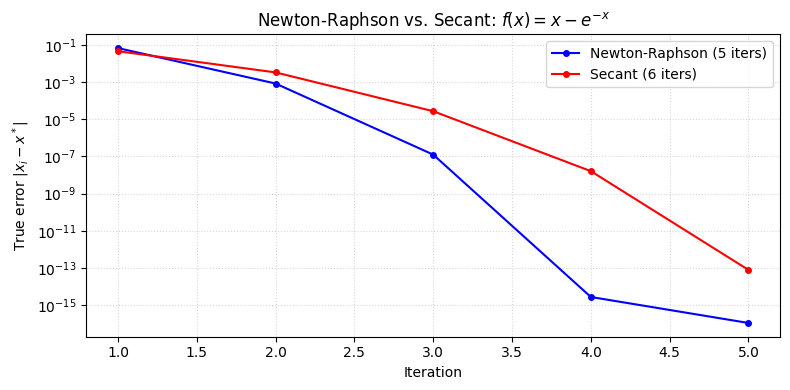

In [29]:
# Compare Newton-Raphson vs Secant on f(x) = x - e^{-x}
xr_sc, fxr_sc, ea_sc, n_sc, hist_sc = secant(f_nr, x0=0.0, x1=1.0, es=1e-12, maxit=30)

print('=== f(x) = x - e^{-x},  true root = 0.5671432904097838 ===')
print(f'Newton-Raphson:  {n_nr} iters,  |error| = {abs(xr_nr - x_true):.3e}')
print(f'Secant:          {n_sc} iters,  |error| = {abs(xr_sc - x_true):.3e}')

# Convergence comparison plot
err_sc = [abs(row[1] - x_true) for row in hist_sc if abs(row[1] - x_true) > 0]
err_nr_plot = [e for e in err_nr if e > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(err_nr_plot)+1), err_nr_plot, 'b.-', ms=8, label=f'Newton-Raphson ({n_nr} iters)')
ax.semilogy(range(1, len(err_sc)+1),      err_sc,      'r.-', ms=8, label=f'Secant ({n_sc} iters)')
ax.set(xlabel='Iteration', ylabel='True error $|x_i - x^*|$',
       title='Newton-Raphson vs. Secant: $f(x)=x-e^{-x}$')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()

In [30]:
# Apply secant method to the bungee jumper problem (no derivative needed!)
xr_sc2, _, _, n_sc2, hist_sc2 = secant(f_bungee, x0=100.0, x1=200.0, es=1e-10)
print(f'Secant (bungee):         m = {xr_sc2:.10f} kg  ({n_sc2} iterations)')
print(f'Newton-Raphson (bungee): m = {xr_nr2:.10f} kg  ({n_nr2} iterations)')
print(f'Bisection (bungee):      m = {xr_bs:.10f} kg  ({len(hist_bs)} iterations)')

Secant (bungee):         m = 142.7376331084 kg  (7 iterations)
Newton-Raphson (bungee): m = 142.7376331084 kg  (4 iterations)
Bisection (bungee):      m = 142.7376331179 kg  (34 iterations)


---
## 7. `scipy.optimize` and Method Comparison

For production code, use `scipy.optimize` which implements robust hybrid algorithms:

- **`brentq`**: Brent's method — combines bisection, secant, and inverse quadratic interpolation.
  Guaranteed convergence (like bisection) but superlinear speed. **Recommended for 1-D problems.**
- **`root_scalar`**: unified interface for all 1-D methods.
- **`fsolve`** / **`root`**: for systems of nonlinear equations.

In [31]:
# scipy.optimize examples
print('=== scipy.optimize: Bungee Jumper ===')

# brentq (recommended)
sol_bq = brentq(f_bungee, 50, 250, xtol=1e-10, full_output=True)
print(f'brentq:         m = {sol_bq[0]:.12f} kg  ({sol_bq[1].iterations} iterations)')

# root_scalar with different methods
for method in ['bisect', 'brentq', 'brenth', 'ridder', 'toms748']:
    try:
        res = root_scalar(f_bungee, bracket=[50, 250], method=method, xtol=1e-10)
        print(f'{method:12s}:  m = {res.root:.12f}  ({res.iterations:3d} iters)')
    except Exception as e:
        print(f'{method:12s}:  ERROR — {e}')

=== scipy.optimize: Bungee Jumper ===
brentq:         m = 142.737633108449 kg  (9 iterations)
bisect      :  m = 142.737633108391  ( 41 iters)
brentq      :  m = 142.737633108449  (  9 iters)
brenth      :  m = 142.737633108450  (  6 iters)
ridder      :  m = 142.737633108495  (  5 iters)
toms748     :  m = 142.737633108450  (  5 iters)


In [32]:
# ============================================================
# Comprehensive method comparison on the bungee jumper problem
# ============================================================
tol = 1e-8

methods = [
    ('Bisection',       bisect,        dict(xl=50, xu=250, es=tol)),
    ('False Position',  false_position, dict(xl=50, xu=250, es=tol)),
    ('Newton-Raphson',  newtraph,       dict(f=f_bungee, fp=fp_bungee, x0=140.0, es=tol)),
    ('Secant',          secant,         dict(f=f_bungee, x0=100.0, x1=200.0, es=tol)),
]

print(f'{"Method":<18}  {"Root":>14}  {"f(root)":>12}  {"Error":>12}  {"Iters":>6}  {"Type":<12}')
print('-' * 84)

for name, func, kwargs in methods:
    if name in ('Bisection', 'False Position'):
        xr_, fxr_, ea_, n_, _ = func(func=f_bungee, **kwargs)
    else:
        xr_, fxr_, ea_, n_, _ = func(**kwargs)
    err_ = abs(xr_ - m_true)
    mtype = 'Bracketing' if name in ('Bisection', 'False Position') else 'Open'
    print(f'{name:<18}  {xr_:>14.8f}  {fxr_:>12.3e}  {err_:>12.3e}  {n_:>6}  {mtype:<12}')

# scipy brentq
sol = brentq(f_bungee, 50, 250, xtol=tol, full_output=True)
print(f'{"scipy brentq":<18}  {sol[0]:>14.8f}  {f_bungee(sol[0]):>12.3e}  '
      f'{abs(sol[0]-m_true):>12.3e}  {sol[1].iterations:>6}  {"Hybrid":<12}')

Method                        Root       f(root)         Error   Iters  Type        
------------------------------------------------------------------------------------
Bisection             142.73763373     1.282e-08     3.373e-05      28  Bracketing  
False Position        142.73763447     2.776e-08     3.447e-05      34  Bracketing  
Newton-Raphson        142.73763311     7.105e-15     3.311e-05       4  Open        
Secant                142.73763311     0.000e+00     3.311e-05       7  Open        
scipy brentq          142.73763311     0.000e+00     3.311e-05       9  Hybrid      


---
## Summary

### Methods Overview

| Method | Family | Convergence Order | Derivative? | Bracket? | Notes |
|--------|--------|------------------|-------------|----------|-------|
| **Bisection** | Bracketing | Linear (rate = 0.5) | No | Yes | Always converges; slowest |
| **False Position** | Bracketing | Superlinear | No | Yes | Can be slower than bisection (one side fixed) |
| **Newton-Raphson** | Open | Quadratic (order 2) | Yes ($f'$) | No | Fastest; may diverge |
| **Secant** | Open | Superlinear (order ≈ 1.618) | No | No | Good compromise; needs two guesses |
| **`scipy.brentq`** | Hybrid | Superlinear | No | Yes | Recommended for production |

### Key Formulas

| Method | Update Formula |
|--------|---------------|
| Bisection | $x_r = \dfrac{x_l + x_u}{2}$ |
| False Position | $x_r = x_u - f(x_u)\,\dfrac{x_l - x_u}{f(x_l) - f(x_u)}$ |
| Newton-Raphson | $x_{i+1} = x_i - \dfrac{f(x_i)}{f'(x_i)}$ |
| Secant | $x_{i+1} = x_i - f(x_i)\,\dfrac{x_{i-1} - x_i}{f(x_{i-1}) - f(x_i)}$ |

### Stopping Criteria

| Criterion | Formula | Notes |
|-----------|---------|-------|
| Approximate relative error | $\varepsilon_a = \left|\frac{x^{\rm new} - x^{\rm old}}{x^{\rm new}}\right|$ | Most common |
| Function value | $|f(x_r)| < \delta$ | Useful when root value is unknown |
| Absolute change | $|x^{\rm new} - x^{\rm old}| < \delta$ | When root is near zero |

### Decision Guide

```
Do you have a bracket [xl, xu]?
  YES → Do you need guaranteed convergence?
          YES → Use Bisection or scipy.brentq
          NO  → Try False Position
  NO  → Do you have f'(x)?
          YES → Use Newton-Raphson (fastest)
          NO  → Use Secant method
```

### Engineering Applications

| Application | Function $f(x)$ | Method | Variable |
|-------------|----------------|--------|----------|
| Bungee jumper velocity | $\sqrt{mg/c_d}\tanh(\cdots) - v = 0$ | Any | Mass $m$ |
| Savings goal | $\frac{12p}{r}[(1+r/12)^n - 1] - A = 0$ | Any | Rate $r$ |
| Circuit operating point | $V - I \cdot R(I) = 0$ | Newton-Raphson | Current $I$ |
| Pipe flow (Colebrook) | Implicit friction factor | Bisection/Secant | $f$ |